# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Five trials are recorded; the uniform phase is complete, so proposals are now trials-informed (uncertainty-aware TPE). Best is trial_05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) at objective 0.0822 (0 diverged, gamma finite; mu rel-RMSE 36.7%, gamma rel-RMSE 21.0%), well below the exp5 honest level and the 0.1074 headline. Then trial_03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) 0.1040; trial_04 (sw 0.959, h_f 2.101, h_s 2.126, cap 0.249) 0.1177; trial_01 (sw 0.409, h_s 3.354, h_f 1.837) 0.1243; trial_02 (sw 0.884, h_f 0.642, h_s 1.007) 0.1287. All 0 diverged, gamma finite. The clear trend: objective falls as the KDE kernels get flatter (h_f, h_s toward their upper bound 4.0), with sw strong-to-moderate (0.84-0.96) and a modest gamma cap (~0.2).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 1.3962 | {"gamma_rel_cap": 0.26188605870799586, "h_f_scale": 1.6543628709545588, "h_s_scale": 3.590422581398607, "sigma_weight": 0.9118381288778405}
 2 | 3.3968 | {"gamma_rel_cap": 0.25490172242726694, "h_f_scale": 3.4382175505329515, "h_s_scale": 3.9203783581948626, "sigma_weight": 0.8632102499091274}
 3 | 3.3994 | {"gamma_rel_cap": 0.10371963310348736, "h_f_scale": 4.0, "h_s_scale": 3.87573660971555, "sigma_weight": 0.49726791274147364}
 4 | 3.1119 | {"gamma_rel_cap": 0.22450954702527456, "h_f_scale": 3.498197794430785, "h_s_scale": 1.8987165906710861, "sigma_weight": 0.8639583474583256}
 5 | 2.8205 | {"gamma_rel_cap": 0.4434822454133109, "h_f_scale": 2.2721766718945173, "h_s_scale": 3.5176820954903523, "sigma_weight": 0.8102057778451616}
 6 | 3.7707 | {"gamma_rel_cap": 0.4406445972244695, "h_f_scale": 3.499956707165928, "h_s_scale": 3.5944848228525483, "sigma_weight": 0.2388055945544003}
 7 | 2.2601 | {"gamma_rel_cap": 0.2350533

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The registry shows a monotone trend: objective falls as the KDE kernels get flatter (trial_05 h_f 3.90/h_s 3.62 -> 0.0822; trial_03 2.45/3.02 -> 0.1040; trial_04 sharpened 2.10/2.13 -> 0.1177; trial_02 0.64/1.01 -> 0.1287), with the sigma weight strong-to-moderate and a modest gamma cap. This is the first trials-informed batch (phase 'trials', 5/5); rows 1-8 are TPE draws with an ei score, rows 9-10 are reserved explore slots.

Candidate 3 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) has the flattest pair of kernels in the batch - h_f exactly at the upper bound and h_s near it - so it is the strongest direct test of the flatness trend, and its moderate sigma weight plus small gamma cap keeps the sigma link meaningful rather than removed. Candidate 2 is similar in ei but keeps h_f lower (3.44); candidate 6 leads on ei only via a low sigma weight (0.24) that the earlier trials already made unattractive (trial_01).

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # candidate 3: sigma_weight 0.497, h_f_scale 4.0, h_s_scale 3.876, gamma_rel_cap 0.104 (flattest kernels)


chosen: {'gamma_rel_cap': 0.10371963310348736, 'h_f_scale': 4.0, 'h_s_scale': 3.87573660971555, 'sigma_weight': 0.49726791274147364}
Running  1nW Trans05 ... 

μ 9.39 -> 5.96 | γ 8.5 -> 3.72 | NLL 0.19


Running  1nW Trans20 ... 

μ 17.32 -> 26.12 | γ 8.5 -> 5.31 | NLL 0.53


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 68.22 | γ 14.1 -> 13.94 | NLL 0.63


Running 3nW Trans100 ... 

μ 175.71 -> 98.48 | γ 14.1 -> 13.82 | NLL 0.61



Total: 7.6 min


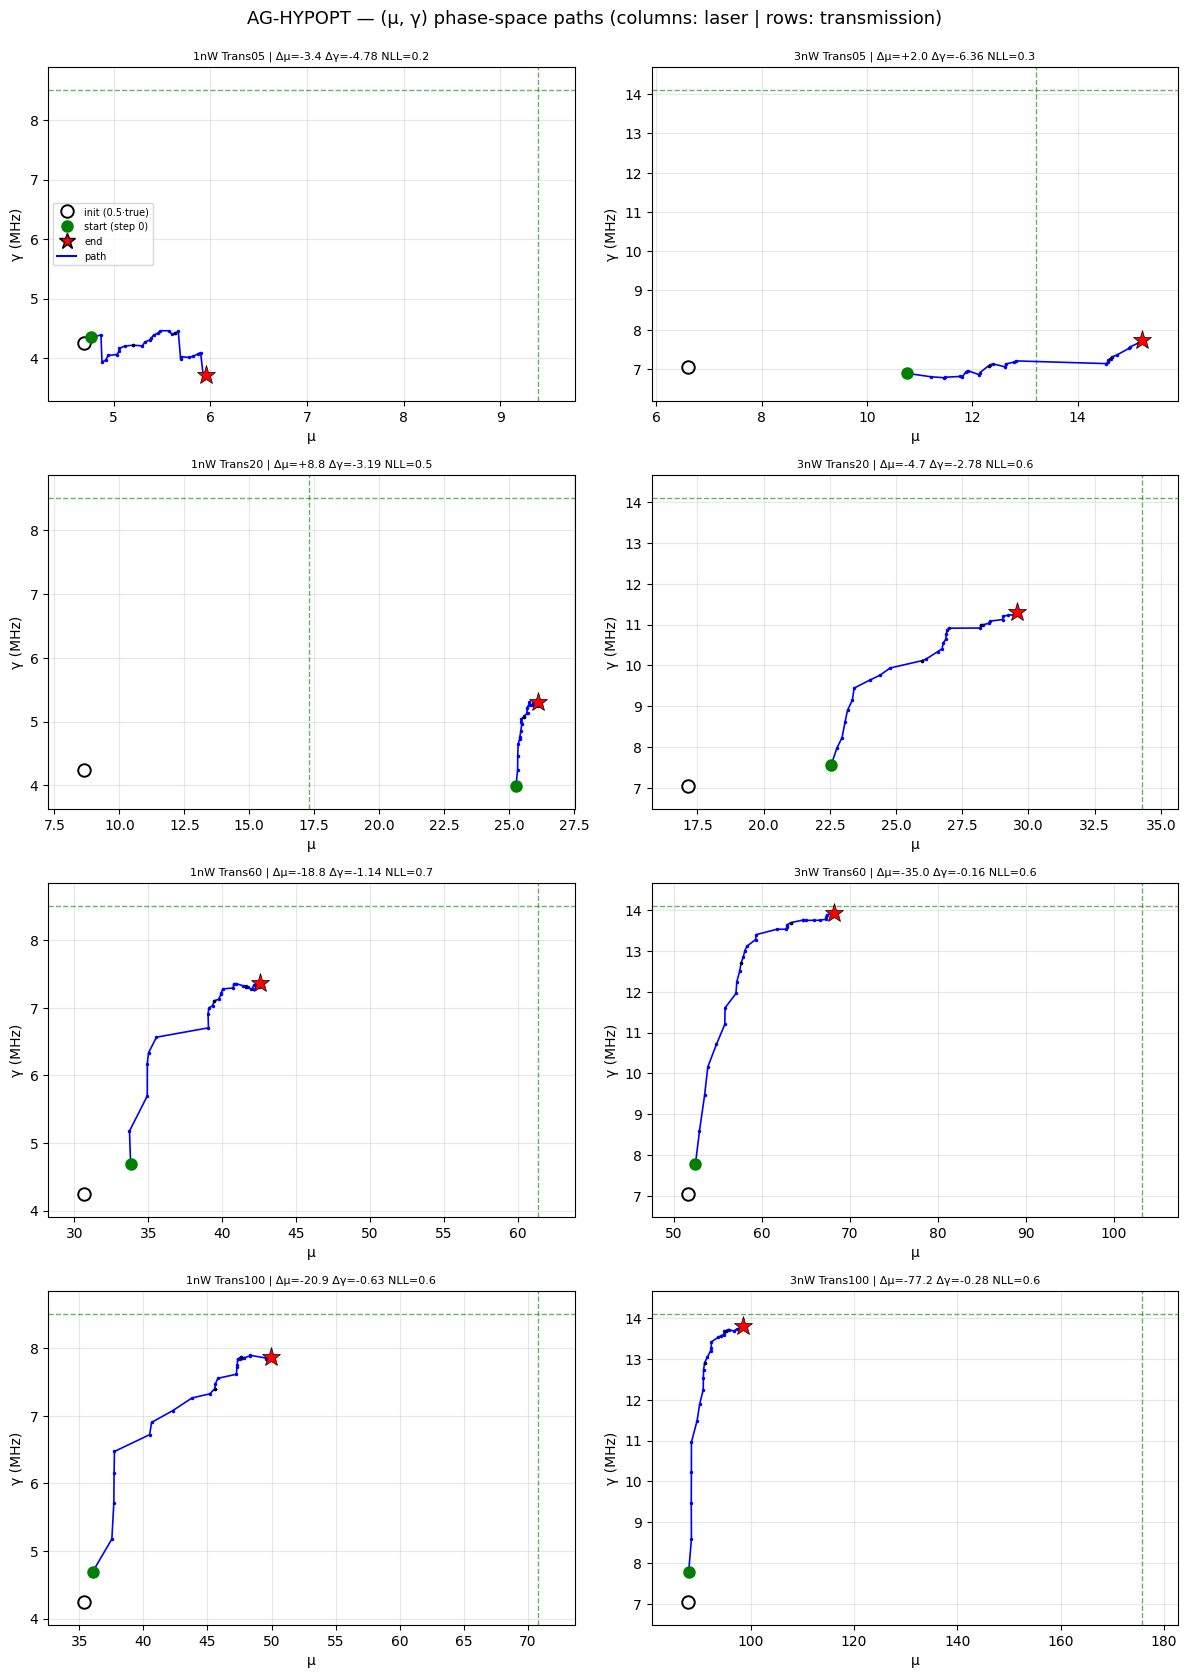

trial finished in 7.6 min
objective = 0.0861 ± 0.0247
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.96   -36.6 |     8.50    3.72   -56.2
1nW Trans20       17.32   26.12   +50.9 |     8.50    5.31   -37.5
1nW Trans60       61.37   42.58   -30.6 |     8.50    7.36   -13.4
1nW Trans100       70.82   49.96   -29.4 |     8.50    7.87    -7.5
3nW Trans05       13.20   15.22   +15.2 |    14.10    7.74   -45.1
3nW Trans20       34.28   29.56   -13.8 |    14.10   11.32   -19.7
3nW Trans60      103.20   68.22   -33.9 |    14.10   13.94    -1.1
3nW Trans100      175.71   98.48   -44.0 |    14.10   13.82    -2.0

weighted objective (T-graded, cap=1.0) = 0.0861 | diverged cells: 0
μ: RMSE 31.805 (rel 34.0%, bias -18.651) | γ: RMSE 3.221 (rel 30.1%, bias -2.415)


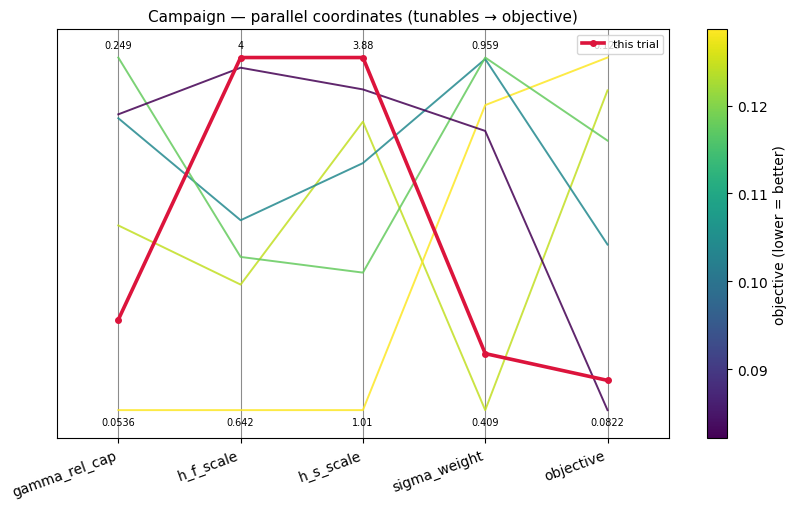

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 06 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) ran to completion in 7.6 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0861 +/- 0.0247 - second best overall, just above trial_05's 0.0822.

mu rel-RMSE 34.0% is the best yet (trial_05 36.7%, trial_03 45.8%): same shape - high-T undershoot (3nW Trans100 -44.0%, 3nW Trans60 -33.9%, 1nW Trans60 -30.6%, 1nW Trans100 -29.4%) and low-T overshoot (1nW Trans20 +50.9%, 3nW Trans05 +15.2%); bias -18.65.

gamma rel-RMSE 30.1% is clearly worse than trial_05's 21.0%, with low T strongly under-estimated (1nW Trans05 -56.2%, 3nW Trans05 -45.1%, 1nW Trans20 -37.5%) and high T near truth (3nW Trans60 -1.1%, 3nW Trans100 -2.0%).

The candidate extended the flatness trend to the kernel boundary (h_f = 4.0, h_s 3.876) but used a moderate sigma weight (0.497) and a small gamma cap (0.104). Versus trial_05, mu improved slightly while gamma degraded, leaving the objective marginally higher - consistent with the sigma weight and gamma cap being responsible for the gamma channel rather than for mu.

**Summary:** Trial 06 (sw=0.497, h_f=4.0, h_s=3.876, cap=0.104) finished in 7.6 min with 0 diverged cells and gamma finite, objective 0.0861 +/- 0.0247 - second best, just above trial_05 (mu rel-RMSE 34.0%, best; gamma rel-RMSE 30.1%, worse).
**Key insight:** Maximally flat kernels with a moderate sigma weight (sw 0.50) matched but did not beat trial_05; the lower sw and smaller gamma cap raised the gamma error (30.1% vs 21.0%), so the best region needs a strong sigma weight together with flat kernels.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 06 (sw=0.497, h_f=4.0, h_s=3.876, cap=0.104): objective 0.0861 +/- 0.0247 - second best, just above trial_05; 0 diverged cells, gamma finite (mu rel-RMSE 34.0% best, gamma rel-RMSE 30.1% worse).'
KEY_INSIGHT = 'Maximally flat kernels with a moderate sigma weight (sw 0.50) matched but did not beat trial_05; the lower sw and smaller gamma cap raised the gamma error (30.1% vs 21.0%), so the best region needs a strong sigma weight together with flat kernels.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
